In [7]:
import numpy as np
import seaborn as sns

sns.set_theme(palette="deep")
sns.set_style("whitegrid")
sns.set_context("poster")

In [8]:
import json


def load_curriculum_results(paths: list[str]):
    results = []
    for path in paths:
        # Calculate offset as the next epoch after the last one we have
        offset = results[-1]["epoch"] + 1 if results else 0

        with open(path, "r") as f:
            pt_results: dict = json.load(f)
            pt_results = [item for item in pt_results["log_history"] if "eval_accuracy" in item]

            pt_results = [
                {"accuracy": item["eval_accuracy"], "epoch": int(item["epoch"]) + offset} for item in pt_results
            ]
            results += pt_results

    accuracy_list = [item["accuracy"] for item in results]

    return accuracy_list

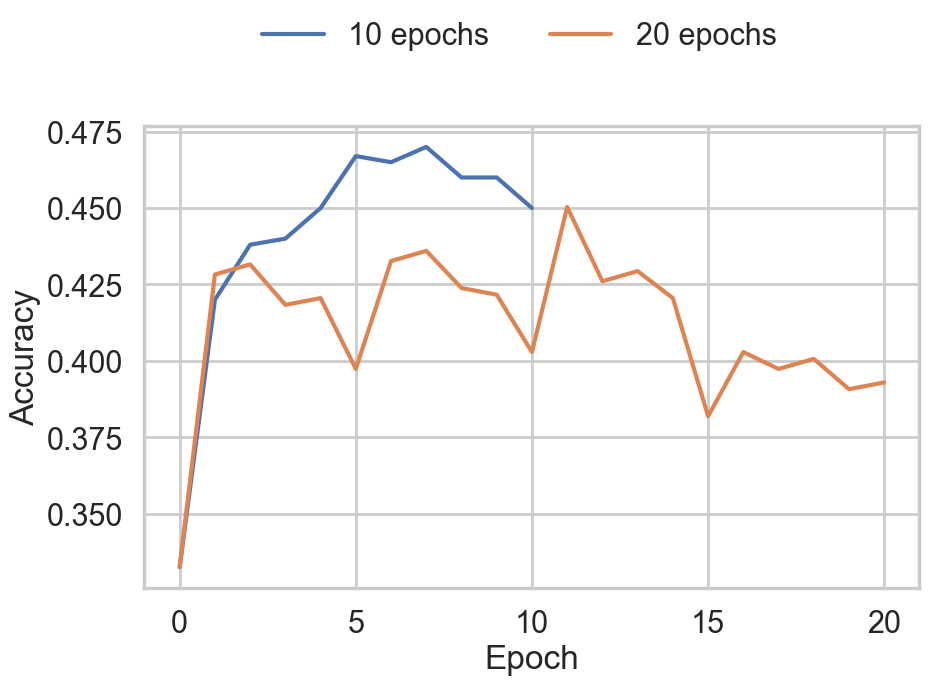

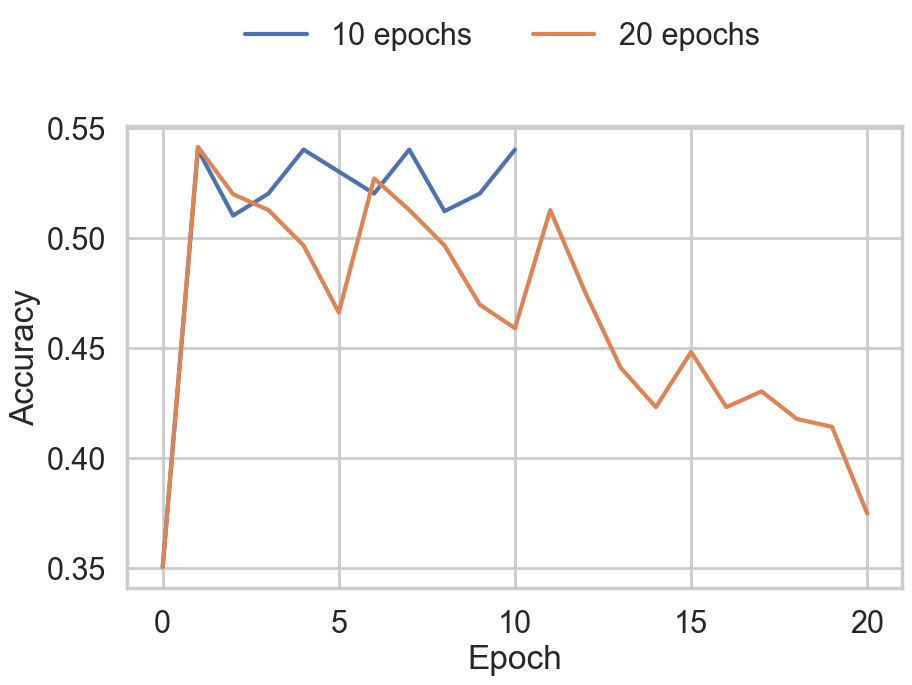

In [9]:
import matplotlib.pyplot as plt

epochs = np.linspace(0, 20, 21)

qwen_sft_curriculum_10epochs = [
    0.332574,
    0.42,
    0.438,
    0.44,
    0.45,
    0.467,
    0.465,
    0.47,
    0.46,
    0.46,
    0.45,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
]
phi_sft_curriculum_10epochs = [
    0.3503,
    0.54,
    0.51,
    0.52,
    0.54,
    0.53,
    0.52,
    0.54,
    0.512,
    0.52,
    0.54,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
    None,
]

qwen_sft_curriculum_20epochs = load_curriculum_results(
    [
        "../../../artifacts/pipeline_20epochs/sft_curriculum/qwen/easy/checkpoint-2250/trainer_state.json",
        "../../../artifacts/pipeline_20epochs/sft_curriculum/qwen/mid/checkpoint-2250/trainer_state.json",
        "../../../artifacts/pipeline_20epochs/sft_curriculum/qwen/hard/checkpoint-4500/trainer_state.json",
    ]
)
phi_sft_curriculum_20epochs = load_curriculum_results(
    [
        "../../../artifacts/pipeline_20epochs/sft_curriculum/phi4/easy/checkpoint-2250/trainer_state.json",
        "../../../artifacts/pipeline_20epochs/sft_curriculum/phi4/mid/checkpoint-2250/trainer_state.json",
        "../../../artifacts/pipeline_20epochs/sft_curriculum/phi4/hard/checkpoint-4500/trainer_state.json",
    ]
)

fig = plt.figure(figsize=(10, 6))

plt.plot(epochs, qwen_sft_curriculum_10epochs, label="10 epochs")
plt.plot(epochs, qwen_sft_curriculum_20epochs, label="20 epochs")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

fig.legend(loc="outside upper center", bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False)
plt.savefig("../../../artifacts/ablations/qwen_sft_curriculum_comparison.pdf", bbox_inches="tight")
plt.show()

fig = plt.figure(figsize=(10, 6))

plt.plot(epochs, phi_sft_curriculum_10epochs, label="10 epochs")
plt.plot(epochs, phi_sft_curriculum_20epochs, label="20 epochs")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

fig.legend(loc="outside upper center", bbox_to_anchor=(0.5, 1.1), ncol=3, frameon=False)
plt.savefig("../../../artifacts/ablations/phi_sft_curriculum_comparison.pdf", bbox_inches="tight")
plt.show()